# Análisis de Homicidios en Colombia

- Juan Diego Grajales Castillo- 20221020128
- Julian David Celis Giraldo  - 20222020041
- Sara Nicolle Martinez Moreno- 20231020116
- David Santiago Aldana Gonzalez - 20222020158

Trabajo de minería de datos con enfoque en limpieza, preparación y análisis exploratorio.

## Estructura del notebook
1. Comprensión del problema
2. Comprensión de los datos
3. Limpieza y preparación
4. EDA (Análisis exploratorio)
5. Conclusiones

## Preparación del entorno
Antes de analizar los datos, verificamos que el entorno tenga todas las librerías necesarias. Esto garantiza reproducibilidad: cualquier persona que abra este notebook puede ejecutar el flujo completo sin errores por dependencias faltantes.

En esta etapa validamos paquetes clave para:
- Carga y transformación de datos (`pandas`, `numpy`).
- Visualización (`matplotlib`, `seaborn`).
- Corrección por similitud textual (`rapidfuzz`).

In [357]:
# Verificar librerias
#!pip install -r requirements.txt
!pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
ipykernel               7.2.0
ipython                 9.11.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.3
packaging               26.0
pandas                  3.0.1
parso                   0.8.6
pexpect                 4.9.0
pillow                  12.1.1
pip                     25.3
platformdirs            4.9.4
prompt_toolkit          3.0.52
psutil                  7.2.2
ptyprocess              0.7.0
pure_eval               0.2.3
Pygments                2.

In [358]:
from rapidfuzz import process
!pip show rapidfuzz

Name: RapidFuzz
Version: 3.14.3
Summary: rapid fuzzy string matching
Home-page: https://github.com/rapidfuzz/RapidFuzz
Author: 
Author-email: Max Bachmann <pypi@maxbachmann.de>
License-Expression: MIT
Location: /home/naciscric/Documents/mineria/.venv/lib/python3.14/site-packages
Requires: 
Required-by: 


<hr>

## 1. Comprensión del problema

### 1.1 Objetivo del análisis

Este estudio persigue identificar y caracterizar patrones de violencia homicida en Colombia según las dimensiones de ubicación territorial, tiempo (día y hora) y características demográficas de las víctimas. Los hallazgos se destinarán a priorizar intervenciones de control y prevención en contextos críticos.

### 1.2 Preguntas de investigación

1. ¿Existe relación entre la hora del día y la frecuencia de homicidios?
2. ¿Cuál es la distribución territorial de los homicidios a nivel departamental?

In [359]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<hr>

## 2. Comprensión de los datos
En esta sección construimos una línea base objetiva del dataset antes de limpiarlo. La idea es responder tres preguntas:
1. ¿Qué tenemos? (tamaño, estructura, tipos).
2. ¿Qué problemas trae? (codificación, nulos, duplicados, categorías inconsistentes).
3. ¿Qué impacto pueden tener esos problemas en el análisis?

### 2.1 Estructura inicial del dataset
- Registros: **11.965 filas**.
- Variables: **20 columnas**.
- Mezcla de variables numéricas, categóricas y temporales.

### 2.2 Qué validamos específicamente
- Integridad estructural (`shape`, `info`).
- Distribuciones generales (`describe`).
- Calidad básica (nulos y duplicados).
- Nombres de columnas con errores de codificación que pueden romper análisis posteriores.

### 2.3 Criterio de trabajo
Primero medimos, luego limpiamos. Evitamos transformar sin diagnóstico para no introducir sesgos ni perder trazabilidad del proceso.

Se carga el archivo CSV con los registros de homicidios. El formato de separación de campos es punto y coma (`;`) en lugar de comas, requiriendo un parámetro explícito durante la lectura.

In [360]:
df = pd.read_csv('Homicidios.csv', sep=';', encoding='latin1')
df.head()

,Fecha,Departamento,Municipio,D¡a,Hora,Barrio,Zona,Clase de sitio,Arma empleada,M¢vil Agresor,M¢vil Victima,Edad,Sexo,Estado civil,Pa¡s de nacimiento,Clase de empleado,Profesi¢n,Escolaridad,C¢digo DANE,Cantidad
0,1/01/2017,AMAZONAS,LETICIA (CT),Domingo,15:05:00,KILOMETRO 11,RURAL,CARRETERA,ARMA BLANCA / CORTOPUNZANTE,PASAJERO MOTOCICLETA,PASAJERO MOTOCICLETA,20,MASCULINO,SOLTERO,COLOMBIA,EMPLEADO PARTICULAR,S.D.,SECUNDARIA,"91,001,000",1
1,1/01/2017,ANTIOQUIA,BETANIA,Domingo,21:20:00,LA CUMBRE,URBANA,VIAS PUBLICAS,ARMA DE FUEGO,A PIE,A PIE,21,MASCULINO,SOLTERO,COLOMBIA,INDEPENDIENTE,S.D.,PRIMARIA,"5,091,000",1
2,1/01/2017,ANTIOQUIA,COPACABANA,Domingo,4:48:00,MACHADO,URBANA,DENTRO DE LA VIVIENDA,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,22,MASCULINO,UNION LIBRE,COLOMBIA,INDEPENDIENTE,S.D.,SECUNDARIA,"5,212,000",1
3,1/01/2017,ANTIOQUIA,EBJICO,Domingo,5:00:00,SAGUA,RURAL,FINCAS Y SIMILARES,ARMA DE FUEGO,A PIE,A PIE,46,MASCULINO,SOLTERO,COLOMBIA,INDEPENDIENTE,S.D.,SECUNDARIA,"5,240,000",1
4,1/01/2017,ANTIOQUIA,EL BAGRE,Domingo,6:30:00,LAS BRISAS,URBANA,VIAS PUBLICAS,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,37,MASCULINO,UNION LIBRE,COLOMBIA,INDEPENDIENTE,S.D.,PRIMARIA,"5,250,000",1


<hr>

## Dimensionalidad del dataset

Se verifica la dimensión del conjunto de datos (número de filas y columnas).

In [361]:
df.shape

(11965, 20)

<hr>

Vistazo general del dataset

In [362]:
df

,Fecha,Departamento,Municipio,D¡a,Hora,Barrio,Zona,Clase de sitio,Arma empleada,M¢vil Agresor,M¢vil Victima,Edad,Sexo,Estado civil,Pa¡s de nacimiento,Clase de empleado,Profesi¢n,Escolaridad,C¢digo DANE,Cantidad
0,1/01/2017,AMAZONAS,LETICIA (CT),Domingo,15:05:00,KILOMETRO 11,RURAL,CARRETERA,ARMA BLANCA / CORTOPUNZANTE,PASAJERO MOTOCICLETA,PASAJERO MOTOCICLETA,20,MASCULINO,SOLTERO,COLOMBIA,EMPLEADO PARTICULAR,S.D.,SECUNDARIA,"91,001,000",1
1,1/01/2017,ANTIOQUIA,BETANIA,Domingo,21:20:00,LA CUMBRE,URBANA,VIAS PUBLICAS,ARMA DE FUEGO,A PIE,A PIE,21,MASCULINO,SOLTERO,COLOMBIA,INDEPENDIENTE,S.D.,PRIMARIA,"5,091,000",1
2,1/01/2017,ANTIOQUIA,COPACABANA,Domingo,4:48:00,MACHADO,URBANA,DENTRO DE LA VIVIENDA,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,22,MASCULINO,UNION LIBRE,COLOMBIA,INDEPENDIENTE,S.D.,SECUNDARIA,"5,212,000",1
3,1/01/2017,ANTIOQUIA,EBJICO,Domingo,5:00:00,SAGUA,RURAL,FINCAS Y SIMILARES,ARMA DE FUEGO,A PIE,A PIE,46,MASCULINO,SOLTERO,COLOMBIA,INDEPENDIENTE,S.D.,SECUNDARIA,"5,240,000",1
4,1/01/2017,ANTIOQUIA,EL BAGRE,Domingo,6:30:00,LAS BRISAS,URBANA,VIAS PUBLICAS,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,37,MASCULINO,UNION LIBRE,COLOMBIA,INDEPENDIENTE,S.D.,PRIMARIA,"5,250,000",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11960,31/12/2017,VALLE,CALI (CT),Domingo,0:31:00,EL POBLADO II E13,URBANA,VIAS PUBLICAS,ARMA DE FUEGO,A PIE,A PIE,19,MASCULINO,SOLTERO,COLOMBIA,EMPLEADO PARTICULAR,S.D.,SECUNDARIA,"76,001,000",1
11961,31/12/2017,VALLE,CARTAGO,Domingo,17:12:00,URB. BELLAVISTA,URBANA,VIAS PUBLICAS,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,30,MASCULINO,SOLTERO,COLOMBIA,DESEMPLEADO,S.D.,PRIMARIA,"76,147,000",1
11962,31/12/2017,VALLE,LA VICTORIA,Domingo,21:20:00,CENTRO,URBANA,VIAS PUBLICAS,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,40,FEMENINO,SOLTERO,COLOMBIA,AMA DE CASA,S.D.,SECUNDARIA,"76,403,000",1
11963,31/12/2017,VICHADA,PUERTO CARRE¥O (CT),Domingo,2:00:00,ACEITICO,RURAL,ISLA,ARMA BLANCA / CORTOPUNZANTE,A PIE,A PIE,45,MASCULINO,SOLTERO,COLOMBIA,INDEPENDIENTE,S.D.,SECUNDARIA,"99,001,000",1


# Modificacion de columnas e informacion de ellas

Se detectan inconsistencias en los nombres de columnas debido a errores de codificación de caracteres (caracteres especiales como `¡`, `¢` reemplazando caracteres ASCII esperados). Estos errores requieren corrección para garantizar la operabilidad del análisis posteriores.

In [363]:
# Renombrar columnas
df.rename(columns={'D¡a': 'Dia', 'M¢vil Agresor': 'Movil Agresor', 'M¢vil Victima': 'Movil Victima', 'Pa¡s de nacimiento': 'Pais de nacimiento', 'Profesi¢n': 'Profesion', 'Escolaridad': 'Escolaridad', 'C¢digo DANE': 'Codigo DANE'}, inplace=True)
df.columns

Index(['Fecha', 'Departamento', 'Municipio', 'Dia', 'Hora', 'Barrio', 'Zona',
       'Clase de sitio', 'Arma empleada', 'Movil Agresor', 'Movil Victima',
       'Edad', 'Sexo', 'Estado civil', 'Pais de nacimiento',
       'Clase de empleado', 'Profesion', 'Escolaridad', 'Codigo DANE',
       'Cantidad'],
      dtype='str')

Una vez estandarizados los nombres, se procede al análisis estructural del conjunto de datos.

In [364]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11965 entries, 0 to 11964
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Fecha               11965 non-null  str  
 1   Departamento        11965 non-null  str  
 2   Municipio           11965 non-null  str  
 3   Dia                 11965 non-null  str  
 4   Hora                11965 non-null  str  
 5   Barrio              11965 non-null  str  
 6   Zona                11965 non-null  str  
 7   Clase de sitio      11965 non-null  str  
 8   Arma empleada       11965 non-null  str  
 9   Movil Agresor       11965 non-null  str  
 10  Movil Victima       11965 non-null  str  
 11  Edad                11965 non-null  int64
 12  Sexo                11965 non-null  str  
 13  Estado civil        11965 non-null  str  
 14  Pais de nacimiento  11965 non-null  str  
 15  Clase de empleado   11965 non-null  str  
 16  Profesion           11965 non-null  str  
 17  Esco

Se generan estadísticas descriptivas para caracterizar el comportamiento distribucional de las variables numéricas.

In [365]:
df.describe(include='all')


,Fecha,Departamento,Municipio,Dia,Hora,Barrio,Zona,Clase de sitio,Arma empleada,Movil Agresor,Movil Victima,Edad,Sexo,Estado civil,Pais de nacimiento,Clase de empleado,Profesion,Escolaridad,Codigo DANE,Cantidad
count,11965,11965,11965,11965,11965,11965,11965,11965,11965,11965,11965,11965.000000,11965,11965,11965,11965,11965,11965,11965,11965.000000
unique,365,32,764,7,1154,5569,2,141,20,11,12,NaN,2,7,17,29,34,8,807,NaN
top,1/01/2017,VALLE,CALI (CT),Domingo,20:00:00,CENTRO,URBANA,VIAS PUBLICAS,ARMA DE FUEGO,A PIE,A PIE,NaN,MASCULINO,SOLTERO,COLOMBIA,EMPLEADO PARTICULAR,S.D.,SECUNDARIA,"76,001,000",NaN
freq,95,2369,1234,2736,182,220,8300,7472,8613,9817,11046,NaN,10904,7188,11745,3816,11785,7151,1234,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.513163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002006
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.104035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044744
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


Se realiza el diagnóstico de valores faltantes en el conjunto de datos.

In [366]:
df.isnull().sum()


Fecha                 0
Departamento          0
Municipio             0
Dia                   0
Hora                  0
Barrio                0
Zona                  0
Clase de sitio        0
Arma empleada         0
Movil Agresor         0
Movil Victima         0
Edad                  0
Sexo                  0
Estado civil          0
Pais de nacimiento    0
Clase de empleado     0
Profesion             0
Escolaridad           0
Codigo DANE           0
Cantidad              0
dtype: int64

Se verifica la existencia de observaciones duplicadas.

In [367]:
df.duplicated().sum()

np.int64(0)

<hr>

# Clasificación de variables

El conjunto de datos contiene variables de naturaleza diversa, que se clasifican según su tipo y pertinencia para el análisis:

## Variables cuantitativas
- **Edad**: escalar numérico, continuo.
- **Hora_num** (derivada): hora del día como entero (0-23).
- **Cantidad**: conteo de incidentes (posteriormente excluida del análisis por no aportar información relevante).

## Variables cualitativas (categóricas)
- **Territorial**: Departamento, Municipio, Barrio, Zona (urbana/rural), Clase de sitio.
- **Temporal**: Día de la semana, Hora.
- **Contextual del hecho**: Arma empleada, Móvil Agresor, Móvil Víctima.
- **Demográfica**: Sexo, Estado civil, País de nacimiento, Profesión, Escolaridad, Clase de empleado.

## Variables excluidas del análisis
- **Código DANE**: código administrativo interno sin relevancia para análisis de patrones.
- **Cantidad**: variable redundante en este contexto.

In [368]:
df["Codigo DANE" and "Cantidad"]

0        1
1        1
2        1
3        1
4        1
        ..
11960    1
11961    1
11962    1
11963    1
11964    1
Name: Cantidad, Length: 11965, dtype: int64

<hr>

## 3. Limpieza y normalización de datos

El proceso de limpieza busca garantizar la integridad analítica del conjunto de datos mediante la eliminación de inconsistencias que pueden afectar la validez de resultados. Específicamente, se abordan:

- **Conversión de tipos de datos**: Variables temporales (`Fecha`, `Hora`) requieren formato específico para análisis cronológico.
- **Estandarización de texto**: Errores de codificación de caracteres en nombres (departamentos, municipios) que fragmentan categorías.
- **Normalización de categorías**: Variaciones menores en escritura que, de no corregirse, generarían conteos fragmentados y gráficos ambiguos.

Sin estas correcciones, una misma categoría podría aparecer bajo múltiples representaciones textuales, invalidando agrupaciones y análisis descriptivos posteriores.

### 3.1 Estandarización de fecha y hora

Las variables de fecha (`Fecha`) y hora (`Hora`) se encuentran codificadas como texto. Se requiere su conversión a tipos de datos temporales nativos de Python para habilitar operaciones cronológicas posteriores (ej: ordenamiento, extracción de componentes).

In [369]:
# Corregir tipo de fecha y crear hora numérica desde texto
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
hora_extraida = df['Hora'].astype(str).str.extract(r'(\d{1,2})')[0]
df['Hora_num'] = pd.to_numeric(hora_extraida, errors='coerce')
df['Hora'] = pd.to_datetime(df['Hora'], format='%H:%M:%S').dt.time
df[['Fecha', 'Hora', 'Hora_num']].head()

,Fecha,Hora,Hora_num
0,2017-01-01,15:05:00,15
1,2017-01-01,21:20:00,21
2,2017-01-01,04:48:00,4
3,2017-01-01,05:00:00,5
4,2017-01-01,06:30:00,6


In [370]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11965 entries, 0 to 11964
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               11965 non-null  datetime64[us]
 1   Departamento        11965 non-null  str           
 2   Municipio           11965 non-null  str           
 3   Dia                 11965 non-null  str           
 4   Hora                11965 non-null  object        
 5   Barrio              11965 non-null  str           
 6   Zona                11965 non-null  str           
 7   Clase de sitio      11965 non-null  str           
 8   Arma empleada       11965 non-null  str           
 9   Movil Agresor       11965 non-null  str           
 10  Movil Victima       11965 non-null  str           
 11  Edad                11965 non-null  int64         
 12  Sexo                11965 non-null  str           
 13  Estado civil        11965 non-null  str           
 14  P

### 3.2 Estandarización de nombres de departamento

Se contabiliza la frecuencia de categorías en la variable `Departamento` para realizar diagnóstico de variantes.

In [371]:
# Extraer los nombres departamentos distintos
original = df['Departamento'].value_counts()
original

Departamento
VALLE                 2369
ANTIOQUIA             1915
CUNDINAMARCA          1555
CAUCA                  561
ATLµNTICO              555
NARI¥O                 530
NORTE DE SANTANDER     506
BOLÖVAR                402
TOLIMA                 315
META                   281
RISARALDA              274
CàRDOBA                258
SANTANDER              234
CHOCà                  228
GUAJIRA                221
CESAR                  209
HUILA                  209
MAGDALENA              201
QUINDÖO                201
CALDAS                 187
CAQUETµ                181
PUTUMAYO               130
SUCRE                  116
ARAUCA                  85
BOYACµ                  75
CASANARE                73
GUAVIARE                38
SAN ANDRS              23
VICHADA                 23
AMAZONAS                 5
GUAINÖA                  3
VAUPS                   2
Name: count, dtype: int64

Se detectan inconsistencias en ortografía de nombres de departamentos. Se implementa un algoritmo de correspondencia difusa (fuzzy matching) para normalizar estas categorías empleando la similitud Levenshtein.

In [372]:
# Función reutilizable para corregir categorías por similitud
def corregir_por_similitud(nombre, catalogo, umbral=80):
    if not isinstance(nombre, str):
        return nombre
    match, score, _ = process.extractOne(nombre, catalogo)
    return match if score >= umbral else nombre

Se define un catálogo normalizado de los 32 departamentos según la división política administrativa de Colombia, sin caracteres acentuados, para servir como referencia en la detección de similitudes.

In [373]:
# Catálogo oficial de departamentos sin tildes (mayúsculas)
departamentos_oficiales = [
    'AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', 'BOLIVAR', 'BOYACA', 'CALDAS',
    'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA', 'GUAINIA',
    'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARINO', 'NORTE DE SANTANDER',
    'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SAN ANDRES', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA',
    'VAUPES', 'VICHADA'
 ]

# Estandarizar nombres
df['Departamento'] = df['Departamento'].apply(
    lambda x: corregir_por_similitud(x, departamentos_oficiales, umbral=80)
 )

# Resumen posterior a la corrección
dept_limpio = df['Departamento'].value_counts()
dept_limpio.head(15)

Departamento
VALLE DEL CAUCA       2369
ANTIOQUIA             1915
CUNDINAMARCA          1555
CAUCA                  561
ATLANTICO              555
NARINO                 530
NORTE DE SANTANDER     506
BOLIVAR                402
TOLIMA                 315
META                   281
RISARALDA              274
CORDOBA                258
SANTANDER              234
CHOCO                  228
LA GUAJIRA             221
Name: count, dtype: int64

Se verifica la consistencia entre el número de categorías antes y después de la estandarización para garantizar integridad de datos.

In [374]:
# Validación rápida: cantidad de categorías antes y después
antes = original.shape[0]
despues = dept_limpio.shape[0]
{'categorias_antes': antes, 'categorias_despues': despues}

{'categorias_antes': 32, 'categorias_despues': 32}

**Estandarizar Municipios**

Se identifican inconsistencias en los nombres de municipios mediante conteo de ocurrencias.

In [375]:
municipios_bd = df['Municipio'].value_counts()
municipios_bd

Municipio
CALI (CT)            1234
BOGOTµ D.C. (CT)     1130
MEDELLÖN (CT)         573
BARRANQUILLA (CT)     346
CéCUTA (CT)           243
                     ... 
VALLE DE SAN JOS       1
EL PE¥àN                1
ENCISO                  1
VITERBO                 1
VILLAPINZàN             1
Name: count, Length: 764, dtype: int64

Se realiza diagnóstico de caracteres no-ASCII mediante análisis de códigos Unicode, identificando aquellos que causan distorsión.

In [376]:
from collections import defaultdict

# Detectar caracteres no ASCII en nombres de municipio
caracteres_raros = defaultdict(list)
for valor in df['Municipio'].dropna().unique():
    for c in valor:
        if ord(c) > 127 and len(caracteres_raros[c]) < 8:
            caracteres_raros[c].append(valor)

print('=== CARACTERES NO ASCII DETECTADOS ===')
for char, ejemplos in caracteres_raros.items():
    print(f'\nCaracter: {repr(char)} (codigo: {ord(char)})')
    for ejemplo in ejemplos:
        print(' -', ejemplo)

=== CARACTERES NO ASCII DETECTADOS ===

Caracter: '\x90' (codigo: 144)
 - EBJICO
 - BELN DE UMBRÖA
 - IBAGU (CT)
 - GUACHEN
 - SAN JOS DE UR
 - SAN JOS DE UR
 - CINAGA
 - SAN ANDRS (CT)

Caracter: 'Ö' (codigo: 214)
 - MEDELLÖN (CT)
 - BOLÖVAR
 - PATÖA
 - MONTERÖA (CT)
 - POTOSÖ
 - PUERTO LEGUÖZAMO
 - BELN DE UMBRÖA
 - JAMUNDÖ

Caracter: 'µ' (codigo: 181)
 - CARTAGENA DEL CHAIRµ
 - POPAYµN (CT)
 - BOGOTµ D.C. (CT)
 - FACATATIVµ
 - ROBERTO PAYµN
 - SANDONµ
 - TULUµ
 - ARBELµEZ

Caracter: '¥' (codigo: 165)
 - NARI¥O
 - EL PE¥OL
 - OCA¥A
 - PIJI¥O DEL CARMEN
 - PE¥OL
 - COVE¥AS
 - BRICE¥O
 - LA MONTA¥ITA

Caracter: 'é' (codigo: 233)
 - CéCUTA (CT)
 - CHINé
 - TIBé
 - TéQUERRES
 - SANTIAGO DE TOLé
 - SAHAGéN
 - MITé (CT)
 - TOLé VIEJO

Caracter: 'à' (codigo: 224)
 - GIRàN
 - APARTADà
 - CHIGORODà
 - QUIBDà (CT)
 - MOMPàS
 - UNIàN PANAMERICANA
 - EL TABLàN DE GàMEZ
 - EL TABLàN DE GàMEZ

Caracter: '\x9a' (codigo: 154)
 - MAGI
 - GEPSA
 - CHACHAGÖ
 - GICµN


Se cuantifican los caracteres problemáticos encontrados en el conjunto de datos.

In [377]:
# Total de caracteres no ASCII detectados
len(caracteres_raros)

7

Se aplica un procedimiento integrado de reemplazo de caracteres y normalización Unicode (NFC) para estandarizar los nombres de municipios.

In [378]:
import unicodedata

def limpiar_municipio(texto):
    if not isinstance(texto, str):
        return texto

    # Reemplazos de codificación observados en el dataset
    reemplazos = {
        'é': 'U', 'É': 'U', 'µ': 'A', '¥': 'N', 'Ö': 'I',
        'à': 'O', '\x90': 'E', '\x9a': 'U', 'Μ': 'A'
    }
    for malo, bueno in reemplazos.items():
        texto = texto.replace(malo, bueno)

    # Quitar tildes restantes y normalizar
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto.upper().strip()

df['Municipio'] = df['Municipio'].apply(limpiar_municipio)
municipios_limpios = df['Municipio'].value_counts()
municipios_limpios.head(20)

Municipio
CALI (CT)               1234
BOGOTA D.C. (CT)        1130
MEDELLIN (CT)            573
BARRANQUILLA (CT)        346
CUCUTA (CT)              243
CARTAGENA (CT)           233
SAN ANDRES DE TUMACO     208
SOACHA                   160
PALMIRA                  154
PEREIRA (CT)             135
SOLEDAD                  130
VILLAVICENCIO (CT)       112
MAICAO                   102
SANTA MARTA (CT)          96
TULUA                     96
QUIBDO (CT)               93
BUCARAMANGA (CT)          91
IBAGUE (CT)               91
ARMENIA (CT)              86
JAMUNDI                   85
Name: count, dtype: int64

**Normalizar dias de la semana**

Se realiza el diagnóstico de inconsistencias en la variable de día de la semana.

In [379]:
dias_original = df['Dia'].value_counts()
dias_original

Dia
Domingo      2736
S bado       1859
Lunes        1716
Viernes      1515
Jueves       1393
Martes       1377
Mircoles    1369
Name: count, dtype: int64

Se aplica el algoritmo de similitud con umbral del 75% para normalizar los valores detección de variantes menores.

In [380]:
# Catálogo oficial de días y normalización por similitud
dias_oficiales = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
df['Dia'] = df['Dia'].apply(lambda x: corregir_por_similitud(x, dias_oficiales, umbral=75))

dias_limpios = df['Dia'].value_counts()
dias_limpios

Dia
Domingo      2736
Sabado       1859
Lunes        1716
Viernes      1515
Jueves       1393
Martes       1377
Miercoles    1369
Name: count, dtype: int64

Se valida que el proceso de normalización conserva la cantidad total de observaciones.

<hr>

# 4. EDA (Análisis exploratorio)
En esta fase convertimos datos limpios en evidencia. Cada gráfico responde una pregunta específica y su interpretación se apoya en cifras exactas del dataset actual.

## Cómo leer esta sección
- Primero: qué distribución o patrón se observa.
- Segundo: dato cuantitativo exacto (casos y porcentaje).
- Tercero: por qué ese patrón es relevante para decisiones de prevención.

### 4.1 Distribución de variables numéricas

Se visualiza la distribución de edad mediante histograma para identificar patrones de concentración etaria.

<function matplotlib.pyplot.show(close=None, block=None)>

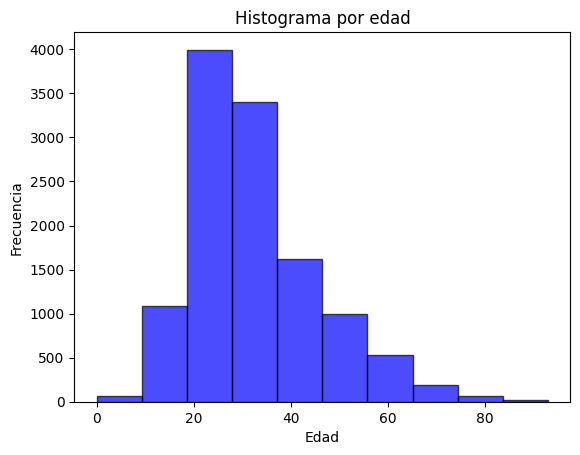

In [381]:
plt.hist(df['Edad'],bins=10, color = 'blue', edgecolor='black', alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma por edad')
plt.show

**Interpretación (con dato exacto):**
La edad se concentra en población joven-adulta. Con base en esta versión del dataset:
- Promedio: **32,51 años**.
- Mediana: **30 años**.
- Q1 = **23** y Q3 = **40**.
- El **77,55%** de los casos está entre **18 y 45 años**.

Esto indica que el riesgo no se distribuye de forma uniforme entre edades, sino que se focaliza en etapas productivas de la vida.

Se calculan estadísticos descriptivos que complementan la visualización gráfica.

In [382]:
df['Edad'].describe()

count    11965.000000
mean        32.513163
std         13.104035
min          0.000000
25%         23.000000
50%         30.000000
75%         40.000000
max         93.000000
Name: Edad, dtype: float64

Se emplea un diagrama de caja (boxplot) para detectar valores atípicos e identificar la dispersión central.

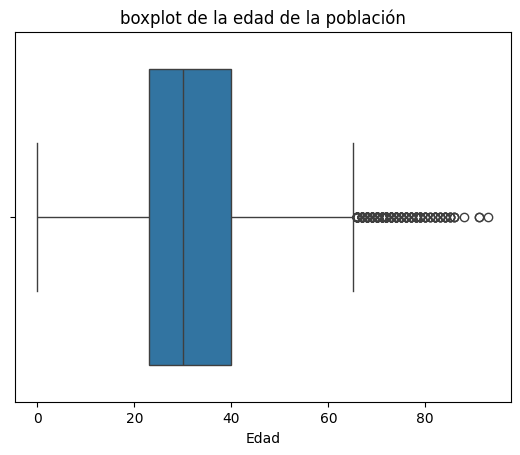

In [383]:
sns.boxplot(x=df['Edad'])
plt.title("boxplot de la edad de la población")
plt.show()

**Interpretación (boxplot e IQR):**
El boxplot confirma concentración central y presencia de valores altos poco frecuentes.
- IQR = **17** (Q1=23, Q3=40).
- Límite superior por regla 1.5*IQR: **65,5 años**.
- Registros por encima/debajo de límites: **267 casos**.

Estos valores atípicos existen, pero no invalidan el patrón general: la mayor densidad de casos sigue en edades jóvenes y adultas tempranas.

Se calculan explícitamente los cuartiles (Q1, Q2, Q3), rango intercuartílico (IQR) y límites de valores atípicos.

In [384]:
Q1 = df['Edad'].quantile(0.25)
Q2 = df['Edad'].quantile(0.50)
Q3 = df['Edad'].quantile(0.75)

IQR = Q3 - Q1

print("IQR", IQR)
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df[(df['Edad'] < lim_inf) | (df['Edad'] > lim_sup)]
outliers[['Edad']]

IQR 17.0


,Edad
99,68
102,78
103,66
133,66
141,66
...,...
11776,77
11859,72
11933,69
11936,72


### 4.2 Análisis de categorías principales

Se analizan variables categóricas clave para construir un perfil multidimensional de los eventos.

Se visualiza la distribución geográfica identificando los diez entes territoriales con mayor concentración.

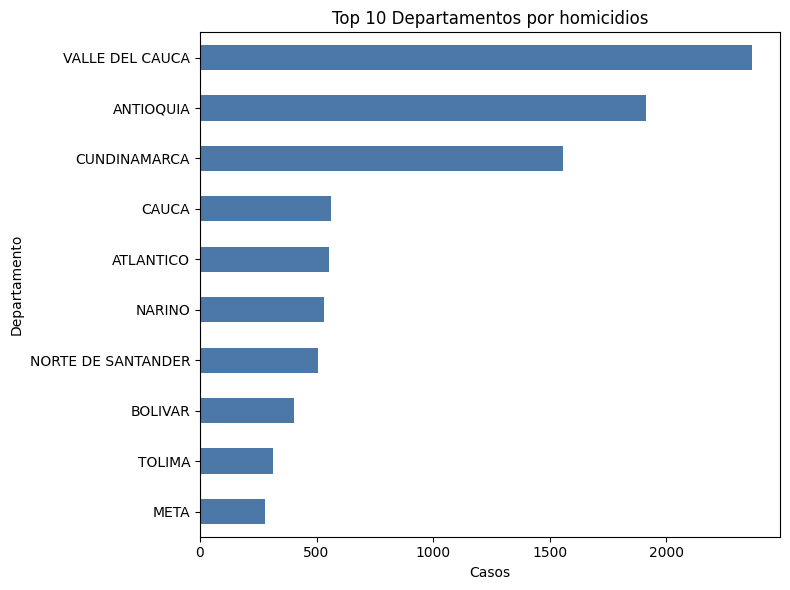

In [385]:
plt.figure(figsize=(8,6))
(df['Departamento'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', color='#4C78A8'))
plt.title('Top 10 Departamentos por homicidios')
plt.xlabel('Casos')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

**Interpretación (Top 10 departamentos):**
La concentración territorial es alta y no homogénea. Casos y participación sobre 11.965 registros:
- Valle del Cauca: **2.369 (19,80%)**
- Antioquia: **1.915 (16,01%)**
- Cundinamarca: **1.555 (13,00%)**
- Cauca: **561 (4,69%)**
- Atlántico: **555 (4,64%)**
- Nariño: **530 (4,43%)**
- Norte de Santander: **506 (4,23%)**
- Bolívar: **402 (3,36%)**
- Tolima: **315 (2,63%)**
- Meta: **281 (2,35%)**

Los tres primeros departamentos concentran **48,81%** del total.

Se ordena cronológicamente la semana para visualizar variaciones en la incidencia diaria.

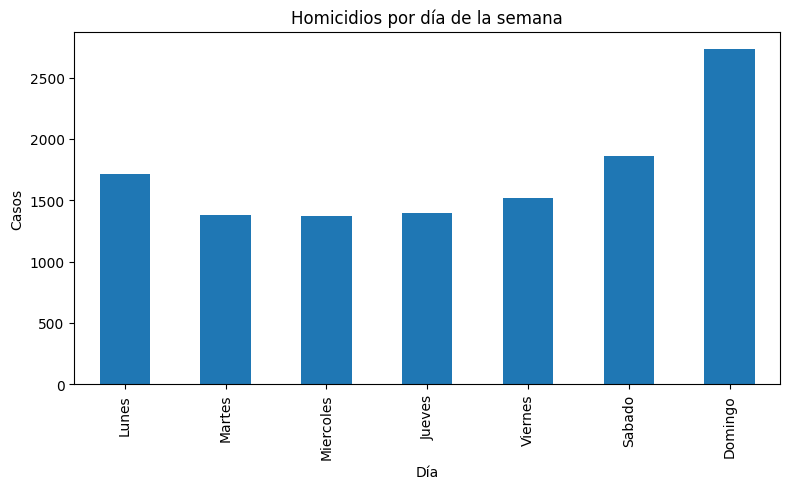

In [386]:
orden_dias = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']

plt.figure(figsize=(8,5))

df['Dia'].value_counts()[orden_dias].plot(kind='bar')

plt.title('Homicidios por día de la semana')
plt.xlabel('Día')
plt.ylabel('Casos')

plt.tight_layout()
plt.show()

**Interpretación (día de la semana):**
Existe un patrón temporal claro:
- Domingo: **2.736 casos (22,87%)**
- Sábado: **1.859 (15,54%)**
- Lunes: **1.716 (14,34%)**

El fin de semana extendido (sábado-domingo-lunes) concentra la mayor carga de casos, por lo que es una ventana crítica para prevención y control situacional.

Se compara la incidencia relativa entre contextos urbanos y rurales.

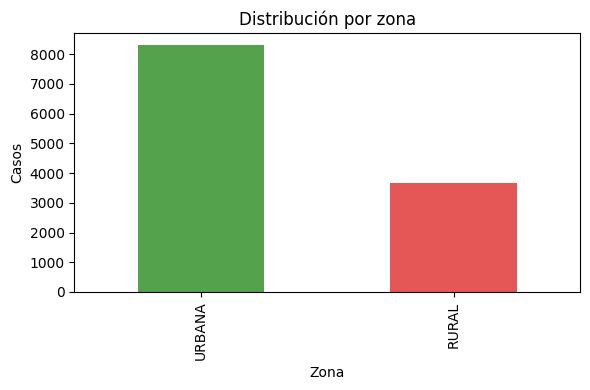

In [387]:
plt.figure(figsize=(6,4))
df['Zona'].value_counts().plot(kind='bar', color=['#54A24B','#E45756'])
plt.title('Distribución por zona')
plt.xlabel('Zona')
plt.ylabel('Casos')
plt.tight_layout()
plt.show()

**Interpretación (zona):**
La mayoría de homicidios ocurre en contexto urbano:
- Urbana: **8.300 casos (69,37%)**
- Rural: **3.665 casos (30,63%)**

La diferencia es de **4.635 casos** a favor de la zona urbana, lo que sugiere priorizar estrategias de intervención en entornos urbanos sin descuidar focos rurales específicos.

Se caracteriza la distribución por tipo de arma, categoría determinante de la modalidad de agresión.

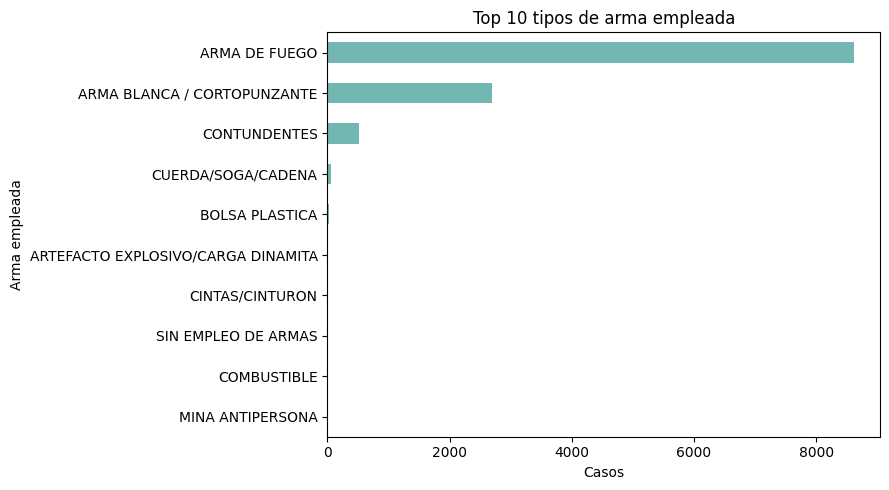

In [388]:
plt.figure(figsize=(9,5))
(df['Arma empleada'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', color='#72B7B2'))
plt.title('Top 10 tipos de arma empleada')
plt.xlabel('Casos')
plt.ylabel('Arma empleada')
plt.tight_layout()
plt.show()

**Interpretación (arma empleada):**
La distribución está fuertemente concentrada en pocas categorías:
- Arma de fuego: **8.613 casos (71,98%)**
- Arma blanca/cortopunzante: **2.687 (22,46%)**
- Contundentes: **517 (4,32%)**

Solo las dos primeras categorías explican **94,44%** de los casos, lo que aporta una señal directa para priorización de políticas de control y prevención.

Se identifican los contextos espaciales de ocurrencia (vías públicas, domicilios, zonas rurales) como factores de caracterización del riesgo.

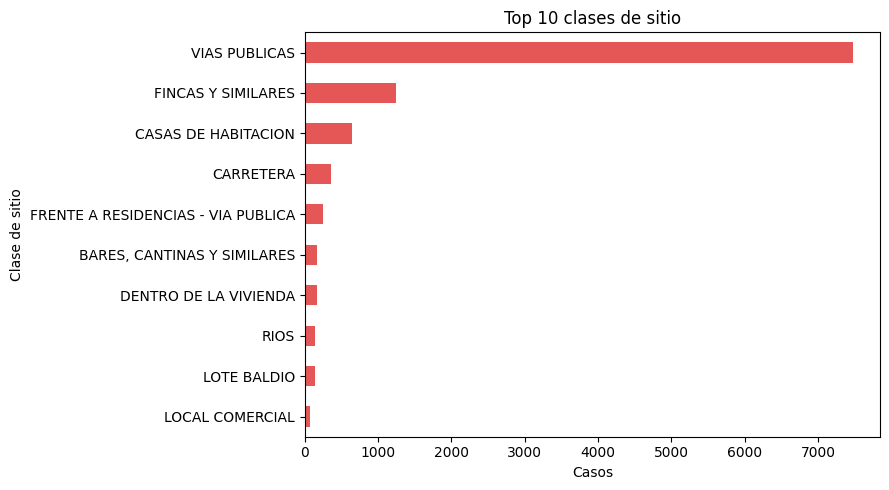

In [389]:
plt.figure(figsize=(9,5))
(df['Clase de sitio'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', color='#E45756'))
plt.title('Top 10 clases de sitio')
plt.xlabel('Casos')
plt.ylabel('Clase de sitio')
plt.tight_layout()
plt.show()

**Interpretación (clase de sitio):**
Los eventos se concentran principalmente en espacio público:
- Vías públicas: **7.472 casos (62,45%)**
- Fincas y similares: **1.251 (10,46%)**
- Casas de habitación: **639 (5,34%)**

La combinación de estos contextos sugiere dinámicas diferenciadas por territorio y tipo de entorno, útiles para focalizar acciones institucionales.

Se analiza la distribución de victimización por sexo de la víctima.

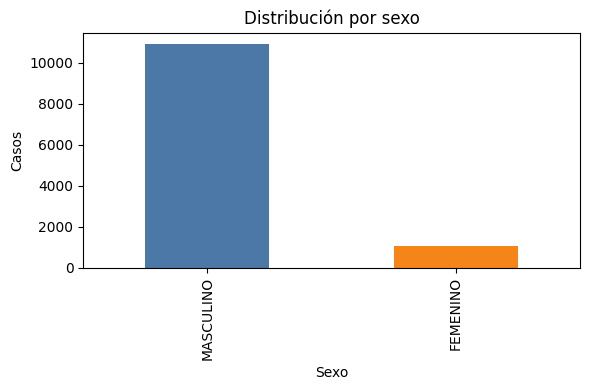

In [390]:
plt.figure(figsize=(6,4))
df['Sexo'].value_counts().plot(kind='bar', color=['#4C78A8','#F58518'])
plt.title('Distribución por sexo')
plt.xlabel('Sexo')
plt.ylabel('Casos')
plt.tight_layout()
plt.show()

**Interpretación (sexo):**
La distribución por sexo es marcadamente asimétrica:
- Masculino: **10.904 casos (91,13%)**
- Femenino: **1.061 casos (8,87%)**

Esta diferencia define un perfil de victimización predominantemente masculino en el periodo analizado.

Se caracteriza el medio de desplazamiento del agresor como variable operativa relevante.

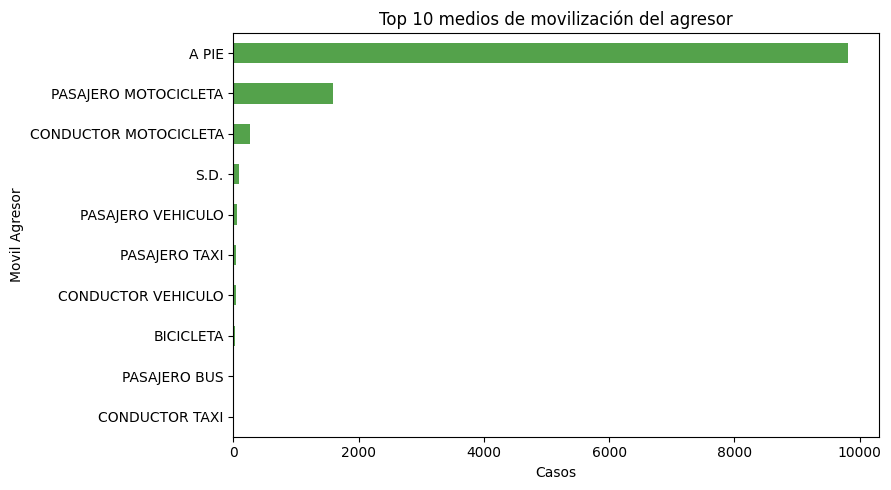

In [391]:
plt.figure(figsize=(9,5))
(df['Movil Agresor'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', color='#54A24B'))
plt.title('Top 10 medios de movilización del agresor')
plt.xlabel('Casos')
plt.ylabel('Movil Agresor')
plt.tight_layout()
plt.show()

**Interpretación (móvil del agresor):**
El patrón dominante es desplazamiento a pie:
- A pie: **9.817 casos (82,05%)**
- Pasajero de motocicleta: **1.586 (13,26%)**
- Conductor de motocicleta: **273 (2,28%)**

Las dos primeras categorías suman **95,31%** de los registros, lo cual aporta información operativa para lectura de modalidad del hecho.

Se examina el medio de desplazamiento de la víctima como indicador de exposición en el momento del evento.

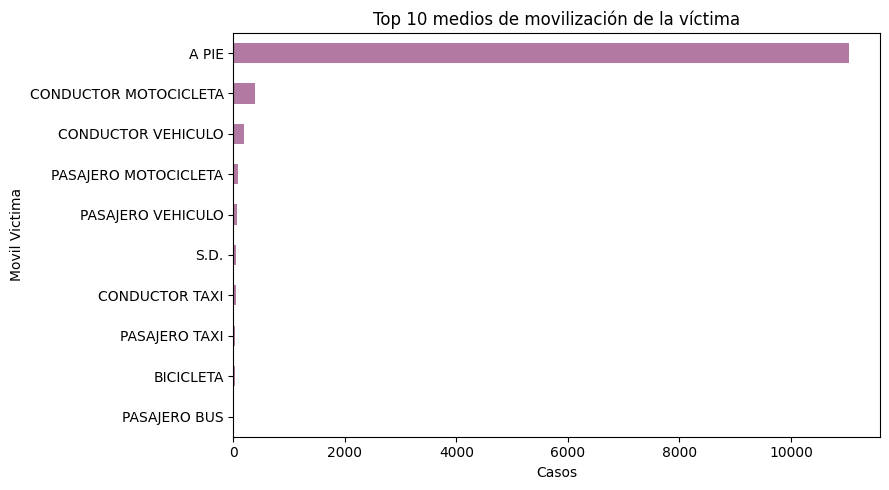

In [392]:
plt.figure(figsize=(9,5))
(df['Movil Victima'].value_counts().head(10)
   .sort_values()
   .plot(kind='barh', color='#B279A2'))
plt.title('Top 10 medios de movilización de la víctima')
plt.xlabel('Casos')
plt.ylabel('Movil Victima')
plt.tight_layout()
plt.show()

**Interpretación (móvil de la víctima):**
También aquí hay una concentración fuerte:
- A pie: **11.046 casos (92,32%)**
- Conductor de motocicleta: **389 (3,25%)**
- Conductor de vehículo: **198 (1,65%)**

La exposición principal ocurre cuando la víctima está a pie, patrón consistente con alta ocurrencia en vías públicas.

### 4.3 Cruces de variables relevantes

Se realizan análisis bivariados para detectar asociaciones significativas entre variables.

Se examina la distribución etaria desagregada por sexo para evaluar diferencias en perfiles de victimización.

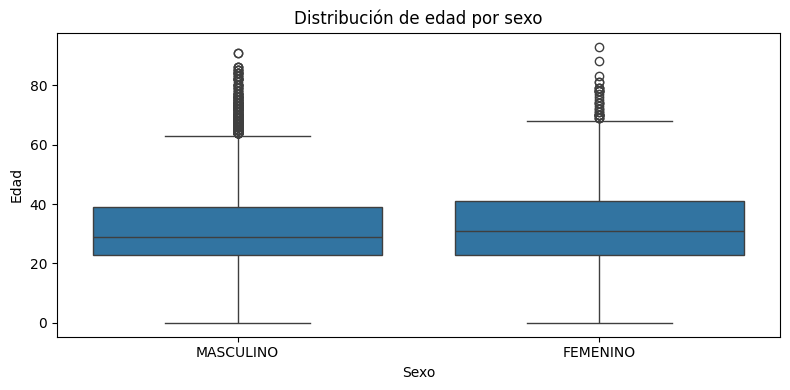

In [393]:
# Cruce Edad x Sexo
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Sexo', y='Edad')
plt.title('Distribución de edad por sexo')
plt.xlabel('Sexo')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

**Interpretación (Edad x Sexo):**
El cruce muestra diferencias moderadas por sexo:
- Mediana de edad: **31 años** (femenino) vs **29 años** (masculino).
- Media de edad: **33,68** (femenino) vs **32,40** (masculino).

La distribución femenina aparece ligeramente desplazada hacia edades mayores, aunque el patrón central en ambos grupos sigue siendo adulto joven.

Se analiza la composición urbano-rural de los principales entes territoriales para orientar intervenciones territoriales diferenciadas.

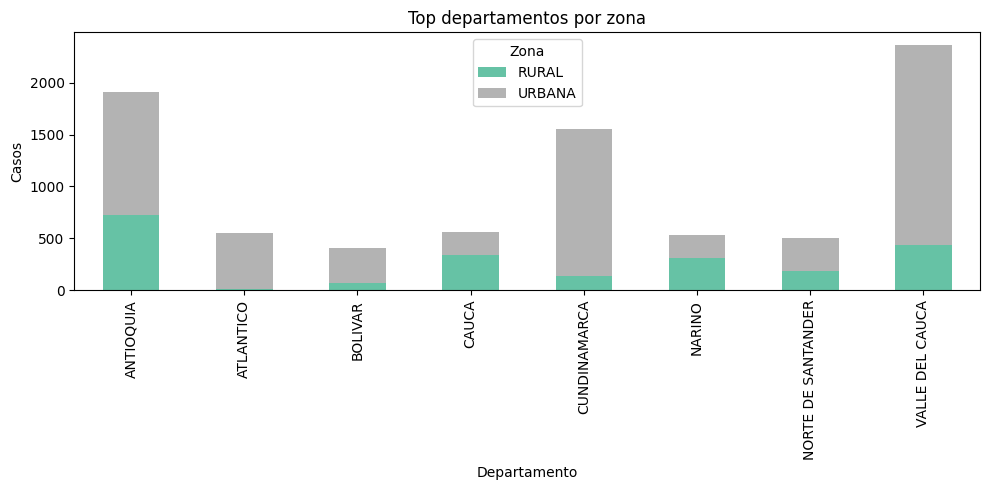

In [394]:
# Cruce Departamento (top 8) x Zona
top_dept = df['Departamento'].value_counts().head(8).index
tabla_dept_zona = pd.crosstab(
    df[df['Departamento'].isin(top_dept)]['Departamento'],
    df[df['Departamento'].isin(top_dept)]['Zona']
 )

tabla_dept_zona.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2')
plt.title('Top departamentos por zona')
plt.xlabel('Departamento')
plt.ylabel('Casos')
plt.tight_layout()
plt.show()

**Interpretación (Departamento x Zona):**
La composición urbano/rural cambia según territorio:
- Atlántico: **98,20% urbano**.
- Cundinamarca: **91,19% urbano**.
- Cauca: **60,78% rural**.
- Nariño: **58,87% rural**.

Esto confirma que no existe una única dinámica territorial; las estrategias deben adaptarse al perfil de cada departamento.

Se construye una matriz de intensidad (heatmap) para identificar las combinaciones espacio-temporales de mayor concentración. 

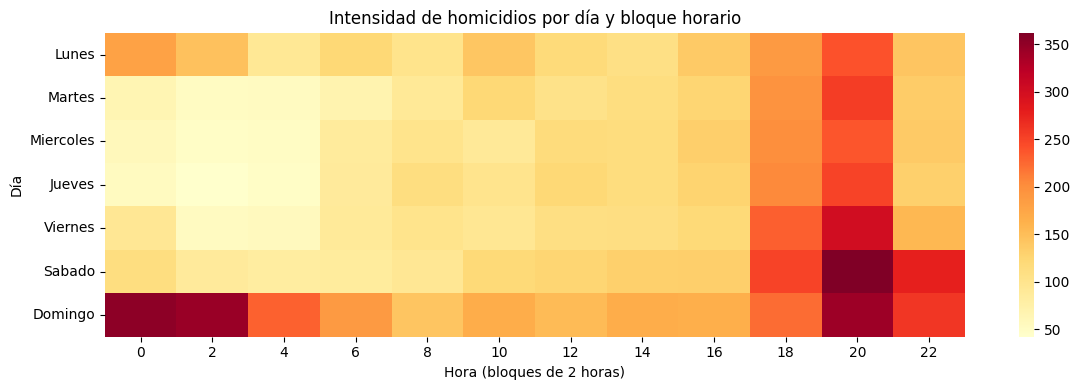

In [395]:
# Cruce Día x Hora en bloques de 2 horas
tabla_dia_hora = (
    df.dropna(subset=['Dia', 'Hora_num'])
      .assign(Hora_bloque=lambda x: (x['Hora_num'] // 2) * 2)
      .pivot_table(index='Dia', columns='Hora_bloque', values='Cantidad', aggfunc='count', fill_value=0)
 )

orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
tabla_dia_hora = tabla_dia_hora.reindex([d for d in orden_dias if d in tabla_dia_hora.index])

if tabla_dia_hora.size == 0:
    print('No hay datos válidos de hora para construir el heatmap.')
else:
    plt.figure(figsize=(12, 4))
    sns.heatmap(tabla_dia_hora, cmap='YlOrRd')
    plt.title('Intensidad de homicidios por día y bloque horario')
    plt.xlabel('Hora (bloques de 2 horas)')
    plt.ylabel('Día')
    plt.tight_layout()
    plt.show()

**Interpretación (Día x Hora):**
El cruce temporal identifica una franja crítica clara.
- Bloque con mayor frecuencia absoluta en la matriz Día-Hora: **sábado 20:00-21:59**, con **362 casos**.
- A nivel global por bloques de 2 horas, lidera **20:00-21:59** con **1.987 casos (16,61%)**.

La intensidad aumenta en horario nocturno y se concentra en fin de semana, respondiendo directamente a la pregunta temporal del análisis.

Se analiza la asociación entre tipo de arma y sexo de la víctima para detectar modalidades diferenciables.

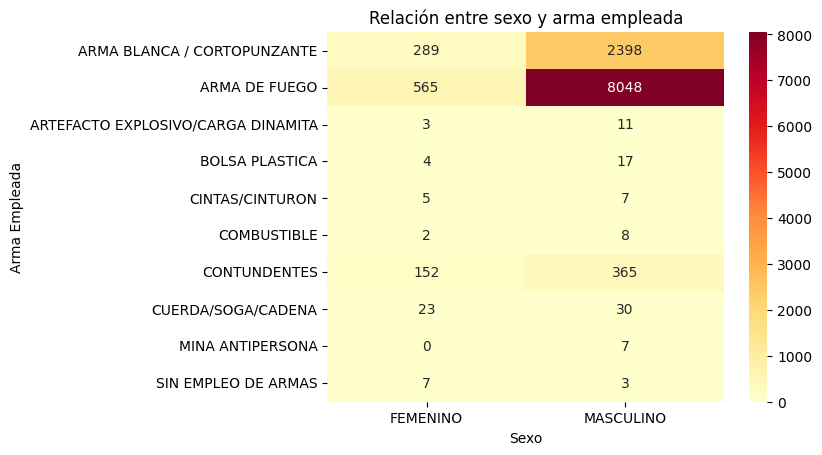

In [396]:
plt.figure()
top_armas = df['Arma empleada'].value_counts().head(10).index
df_top=df[df['Arma empleada'].isin(top_armas)]
tabla = pd.crosstab(df_top['Arma empleada'],df_top['Sexo'])
sns.heatmap(tabla,annot=True,fmt='d',cmap='YlOrRd')
plt.title("Relación entre sexo y arma empleada")
plt.xlabel("Sexo")
plt.ylabel("Arma Empleada")
plt.show()

**Interpretación (Arma x Sexo):**
En ambos sexos predomina el uso de arma de fuego y luego arma cortopunzante:
- Masculino: arma de fuego **8.048**, arma blanca/cortopunzante **2.398**.
- Femenino: arma de fuego **565**, arma blanca/cortopunzante **289**.

El patrón de tipo de arma es consistente entre grupos, aunque con mayor volumen absoluto en población masculina por su mayor participación en el total de casos.

---

## 5. Conclusiones

Los hallazgos que siguen se basan en el análisis del conjunto de datos ya limpio y normalizado. Todos los valores presentados son exactos y reproducibles mediante ejecución de las celdas de análisis anteriores.

### 5.1 Hallazgos concretos

1. **Tamaño del análisis**
- Total de registros analizados: **11.965**.

2. **Perfil de edad (rangos con casos y porcentaje)**
- 26-35 años: **3.670 casos (30,67%)**.
- 18-25 años: **3.530 casos (29,50%)**.
- 36-45 años: **2.079 casos (17,38%)**.
- 46-60 años: **1.446 casos (12,09%)**.
- 0-17 años: **764 casos (6,39%)**.
- 61+ años: **476 casos (3,98%)**.

En conjunto, el grupo **18-35 años concentra 60,17%** de los casos.

3. **Concentración territorial (Top 10 departamentos)**
- Valle del Cauca: **2.369 (19,80%)**.
- Antioquia: **1.915 (16,01%)**.
- Cundinamarca: **1.555 (13,00%)**.
- Cauca: **561 (4,69%)**.
- Atlántico: **555 (4,64%)**.
- Nariño: **530 (4,43%)**.
- Norte de Santander: **506 (4,23%)**.
- Bolívar: **402 (3,36%)**.
- Tolima: **315 (2,63%)**.
- Meta: **281 (2,35%)**.

Los tres primeros concentran **48,81%** del total.

4. **Patrón temporal (día y hora)**
- Día con más casos: **Domingo (2.736; 22,87%)**.
- Le siguen: **Sábado (1.859; 15,54%)** y **Lunes (1.716; 14,34%)**.
- Bloques de 2 horas con más casos a nivel global:
  - **20:00-21:59:** 1.987 casos (16,61%).
  - **18:00-19:59:** 1.491 (12,46%).
  - **22:00-23:59:** 1.239 (10,36%).

La combinación puntual más alta en el cruce Día-Hora es **sábado 20:00-21:59 (362 casos)**.

5. **Contexto del hecho (categorías dominantes)**
- **Arma empleada:**
  - Arma de fuego: **8.613 (71,98%)**.
  - Arma blanca/cortopunzante: **2.687 (22,46%)**.
- **Clase de sitio:**
  - Vías públicas: **7.472 (62,45%)**.
  - Fincas y similares: **1.251 (10,46%)**.
  - Casas de habitación: **639 (5,34%)**.
- **Zona:** Urbana **8.300 (69,37%)** vs Rural **3.665 (30,63%)**.
- **Móvil agresor:** A pie **9.817 (82,05%)**; pasajero motocicleta **1.586 (13,26%)**.
- **Móvil víctima:** A pie **11.046 (92,32%)**; conductor motocicleta **389 (3,25%)**.

6. **Cruces relevantes**
- **Edad por sexo:**
  - Mediana: femenino **31** vs masculino **29**.
  - Media: femenino **33,68** vs masculino **32,40**.
- **Departamento-zona (top 8):**
  - Más urbanos: Atlántico (**98,20% urbano**) y Cundinamarca (**91,19% urbano**).
  - Mayor peso rural: Cauca (**60,78% rural**) y Nariño (**58,87% rural**).

### 5.2 Respuesta a las preguntas del problema

- **¿Existe relación entre tiempo y cantidad de homicidios?** Sí. Hay concentración clara en fin de semana y franja nocturna, con pico en **20:00-21:59**.
- **¿Cuál es el departamento con mayor concentración de homicidios?** **Valle del Cauca**, con **2.369 casos (19,80%)**.

### 5.3 Implicaciones prácticas

1. Priorizar intervención territorial en los departamentos de mayor concentración (especialmente Valle del Cauca, Antioquia y Cundinamarca).
2. Reforzar acciones preventivas en ventanas críticas de tiempo (sábado-domingo-lunes, noche).
3. Focalizar estrategias situacionales en contexto urbano, vías públicas y control de violencia con arma de fuego.

### 5.4 Alcance del análisis

Este estudio es **descriptivo-exploratorio**: identifica concentraciones y patrones observables en los datos, pero no establece causalidad por sí mismo.